In [1]:
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torchvision

In [2]:
#image classification usually 32x3x224x224 - minibatch size, channels, height, width
#output is 3 cause lets say we have 3 classes

from sklearn.datasets import make_circles

In [3]:
n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [4]:
print(f"X: {X[:5]}")
print(f"y: {y[:5]}")

X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
y: [1 1 1 1 0]


<Axes: >

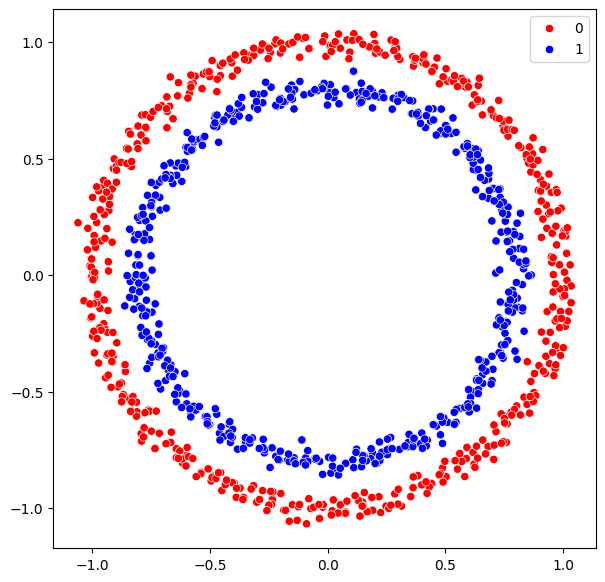

In [5]:
import seaborn as sns
plt.figure(figsize=(7, 7))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette=["red", "blue"])

In [6]:
circles = pd.DataFrame(
    {'X1': X[:, 0], 'X2': X[:, 1], 'label': y}
)

circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


<Axes: xlabel='X1', ylabel='X2'>

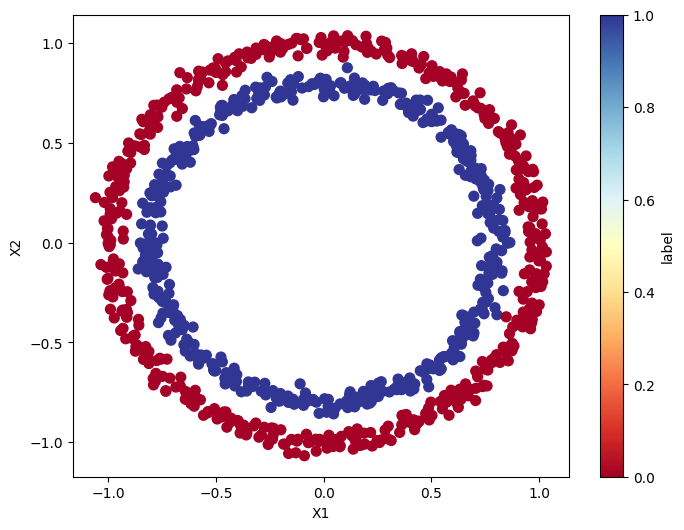

In [7]:
circles.plot.scatter(x='X1', y='X2', c='label', cmap=plt.cm.RdYlBu, figsize=(8, 6), s=50)

In [8]:
#toy dataset is not linearly separable, so we need a non-linear model to classify it. We can use a neural network with non-linear activation functions to achieve this. Let's create a simple feedforward neural network for this classification task.
#### check input and output shapes
print(f"Input shape: {X.shape}")
print(f"Output shape: {y.shape}")

Input shape: (1000, 2)
Output shape: (1000,)


In [9]:
X_sample = X[0]
y_sample = y[0]

print(f'Values of X_sample: {X_sample} and shape: {X_sample.shape}')
print(f'Values of y_sample: {y_sample} and shape: {y_sample.shape}')

Values of X_sample: [0.75424625 0.23148074] and shape: (2,)
Values of y_sample: 1 and shape: ()


In [10]:
## create tensor dataset and dataloader

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## build a model

Lets build a model to classify blue and red dots

1. Device agnostic - mps/cuda/ of CPU
2. construct a model through nn.Module
3. define a loss and optimizer
4. create a train and test loop

In [13]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
device

'mps'

In [14]:
X_train.shape

torch.Size([800, 2])

1. subclass 'nn.Module' 
2. create nn.Linear layer capable of handling the shapes of our data
3. define a forward() method (forward pass)
4. instatiate an instance of pur model class

In [15]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # create 2 linear layers and 1 non-linear activation function
        self.layer_1 = nn.Linear(in_features=2, out_features=5) #takes 2 features and outputs 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) #outputs 1 feature for binary classification

    def forward(self, x):
        return self.layer_2(self.layer_1(x)) #pass input through layer 1 and then layer 2

In [16]:
model_0 = CircleModelV1().to(device) # send model to device (GPU or CPU)

In [17]:
model_0

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [18]:
next(model_0.parameters()).device

device(type='mps', index=0)

In [19]:
# lets replicate using nn.Sequential

model_1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

In [20]:
model_1

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [21]:
model_1.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5038, -0.0671],
                      [-0.6362, -0.4423],
                      [-0.2441,  0.7059],
                      [ 0.2821, -0.2306],
                      [-0.0075, -0.0669]], device='mps:0')),
             ('0.bias',
              tensor([-8.8508e-06,  1.0967e-04, -3.6342e-01, -4.3564e-01,  3.8944e-01],
                     device='mps:0')),
             ('1.weight',
              tensor([[-0.2855,  0.1449,  0.0249,  0.1444, -0.1770]], device='mps:0')),
             ('1.bias', tensor([0.3027], device='mps:0'))])

In [22]:
with torch.inference_mode():
    untrained_preds = model_1(X_test.to(device))
print(f"Length of untrained predictions: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f'Length of y_test: {len(y_test)}, shape: {y_test.shape}')
print(f"First 10 untrained predictions: {untrained_preds[:10]}")
print(f"First 10 y_test: {y_test[:10]}")

Length of untrained predictions: 200, shape: torch.Size([200, 1])
Length of y_test: 200, shape: torch.Size([200])
First 10 untrained predictions: tensor([[ 0.2036],
        [ 0.1119],
        [ 0.3178],
        [ 0.1718],
        [ 0.1176],
        [ 0.0632],
        [-0.0363],
        [-0.0482],
        [ 0.3261],
        [ 0.1036]], device='mps:0')
First 10 y_test: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [23]:
## 2.1 set up loss function and optimizer

loss_fn = nn.BCEWithLogitsLoss() # for classification tasks, we can use binary cross entropy with logits loss function - combines a sigmoid layer and the BCELoss in one single class. This version is more numerically stable than using a plain Sigmoid followed by a BCELoss as, by combining the operations into one layer, we take advantage of the log-sum-exp trick for numerical stability.
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.01)

In [24]:
# calc accuracy function
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## train model

1. forward pass
2. calc loss
3. optimizer zero grad
4. backward propogation
5. optimizer step

model_1

In [25]:
model_1

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [26]:
model_1.eval() # squeeze to remove extra dimensions #view 5 first  logits
with torch.inference_mode():
    y_logits = model_1(X_test.to(device))[:5] # squeeze to remove extra dimensions #view 5 first  logits
y_logits
# logits are the raw outputs of the model, which can be any real number. To convert these logits into probabilities, we can apply a sigmoid function. The sigmoid function squashes the logits into a range between 0 and 1, which can then be interpreted as probabilities for binary classification tasks.

tensor([[0.2036],
        [0.1119],
        [0.3178],
        [0.1718],
        [0.1176]], device='mps:0')

In [27]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [28]:
#use sigmoid function to convert logits to probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5507],
        [0.5280],
        [0.5788],
        [0.5428],
        [0.5294]], device='mps:0')

In [29]:
torch.round(y_pred_probs)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], device='mps:0')

for out prediction prob values we need a range-style rounding on them:
* y_pred_prods >= 0.5, y=1 (class 1)
* y_pred_probs < 0.5, y=0 (class 0)

In [30]:
# create prediction labels by rounding the probabilities to the nearest integer (0 or 1)
y_pred = torch.round(y_pred_probs)
y_pred_labels = torch.round(torch.sigmoid(model_1(X_test.to(device))[:5]))
print(torch.eq(y_pred_labels.squeeze(), y_test.squeeze()[:5].to(device)))
y_pred.squeeze()

tensor([ True, False,  True, False,  True], device='mps:0')


tensor([1., 1., 1., 1., 1.], device='mps:0')

In [31]:
# build a training loop to train the model on the dataset. The training loop will iterate over the dataset multiple times (epochs), and in each epoch, it will perform forward propagation, compute the loss, perform backpropagation, and update the model's parameters using the optimizer.
torch.manual_seed(42)

torch.mps.manual_seed(42) if torch.backends.mps.is_available() else None

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train() # set model to training mode
    #1 forward pass
    y_logits = model_1(X_train).squeeze() # forward pass
    y_pred = torch.round(torch.sigmoid(y_logits)) # convert logits to probabilities and round to get predictions
    #2 compute loss and accuracy
    loss = loss_fn(y_logits, y_train) # compute loss #BCEWithLogitsLoss expects logits as input, so we pass y_logits instead of y_pred
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred) # compute accuracy
    # 3 backpropagation and optimization
    optimizer.zero_grad() # zero the gradients
    # 4 loss backward and optimizer step
    loss.backward() # backpropagation
    optimizer.step() # update parameters

    # test
    model_1.eval() # set model to evaluation mode
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze() # forward pass
        test_pred = torch.round(torch.sigmoid(test_logits)) # convert logits to probabilities and round to get predictions
        test_loss = loss_fn(test_logits, y_test) # compute loss
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred) # compute accuracy

    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.6993 | Accuracy: 58.25% | Test Loss: 0.6953 | Test Accuracy: 57.50%
Epoch: 20 | Loss: 0.6987 | Accuracy: 55.38% | Test Loss: 0.6948 | Test Accuracy: 60.50%
Epoch: 40 | Loss: 0.6981 | Accuracy: 53.75% | Test Loss: 0.6944 | Test Accuracy: 58.00%
Epoch: 60 | Loss: 0.6976 | Accuracy: 52.50% | Test Loss: 0.6941 | Test Accuracy: 57.50%
Epoch: 80 | Loss: 0.6972 | Accuracy: 52.75% | Test Loss: 0.6938 | Test Accuracy: 56.50%
Epoch: 100 | Loss: 0.6968 | Accuracy: 52.25% | Test Loss: 0.6935 | Test Accuracy: 56.50%
Epoch: 120 | Loss: 0.6965 | Accuracy: 52.25% | Test Loss: 0.6934 | Test Accuracy: 54.50%
Epoch: 140 | Loss: 0.6962 | Accuracy: 51.88% | Test Loss: 0.6932 | Test Accuracy: 54.50%
Epoch: 160 | Loss: 0.6960 | Accuracy: 51.62% | Test Loss: 0.6931 | Test Accuracy: 53.00%
Epoch: 180 | Loss: 0.6957 | Accuracy: 51.38% | Test Loss: 0.6929 | Test Accuracy: 51.50%
Epoch: 200 | Loss: 0.6955 | Accuracy: 51.75% | Test Loss: 0.6929 | Test Accuracy: 52.50%
Epoch: 220 | Loss: 0.6954 |

In [32]:
# 4. make predictions with the trained model and visualize the decision boundary. The decision boundary is the line (or curve) that separates the different classes in the feature space. We can visualize how well our model has learned to classify the data by plotting the decision boundary along with the data points.

In [33]:
import requests
from pathlib import Path

# download helper functions from GitHub
if Path('helper_functions.py').is_file():
    print("helper_functions.py already exists, skipping download.")
else:
    url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py"
    response = requests.get(url)
    with open("helper_functions.py", "wb") as f:
        f.write(response.content)
    print("Downloaded helper_functions.py from GitHub.")

helper_functions.py already exists, skipping download.


In [34]:
import torchvision

In [35]:
from helper_functions import plot_predictions, plot_decision_boundary

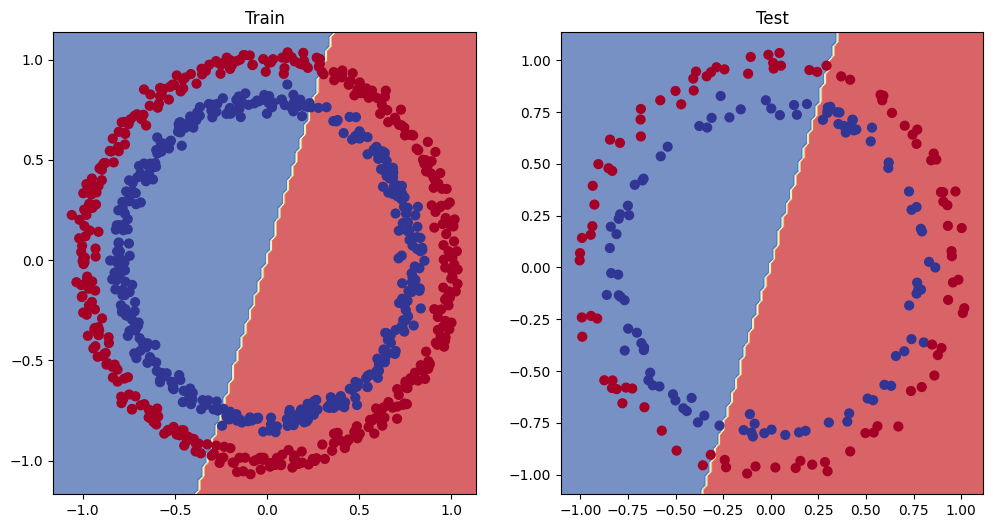

In [37]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [38]:
model_1.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4671, -0.0815],
                      [-0.6236, -0.4372],
                      [-0.2365,  0.7089],
                      [ 0.3093, -0.2200],
                      [-0.0374, -0.0786]])),
             ('0.bias', tensor([ 0.0238, -0.0100, -0.3673, -0.4508,  0.4069])),
             ('1.weight',
              tensor([[-0.2205,  0.0293,  0.0626,  0.2137, -0.2196]])),
             ('1.bias', tensor([0.2139]))])

In [ ]:
# class CircleModelV2(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.layer_1 = nn.Linear(in_features=2, out_features=10)

## introduce nonlinear activation function

In [39]:
X_train.type

<function Tensor.type>

In [56]:
# build a model with a non-linear activation function (ReLU) to improve the model's ability to learn complex patterns in the data. The ReLU activation function introduces non-linearity into the model, allowing it to capture more complex relationships between the input features and the target labels.
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # ReLU activation function

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x) # apply ReLU activation
        x = self.layer_2(x)
        x = self.relu(x) # apply ReLU activation
        x = self.layer_3(x)
        # x = self.relu(x) # apply ReLU activation
        return x

model_2 = CircleModelV2().to(device)
model_2

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [57]:
loss_fn = nn.BCEWithLogitsLoss() # for classification tasks, we can use binary cross entropy with logits loss function - combines a sigmoid layer and the BCELoss in one single class. This version is more numerically stable than using a plain Sigmoid followed by a BCELoss as, by combining the operations into one layer, we take advantage of the log-sum-exp trick for numerical stability.
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.03)

In [58]:
# build a training loop to train the model on the dataset. The training loop will iterate over the dataset multiple times (epochs), and in each epoch, it will perform forward propagation, compute the loss, perform backpropagation, and update the model's parameters using the optimizer.
torch.manual_seed(42)

torch.mps.manual_seed(42) if torch.backends.mps.is_available() else None

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_2.train() # set model to training mode
    #1 forward pass
    y_logits = model_2(X_train).squeeze() # forward pass
    y_pred = torch.round(torch.sigmoid(y_logits)) # convert logits to probabilities and round to get predictions
    #2 compute loss and accuracy
    loss = loss_fn(y_logits, y_train) # compute loss #BCEWithLogitsLoss expects logits as input, so we pass y_logits instead of y_pred
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred) # compute accuracy
    # 3 backpropagation and optimization
    optimizer.zero_grad() # zero the gradients
    # 4 loss backward and optimizer step
    loss.backward() # backpropagation
    optimizer.step() # update parameters

    # test
    model_2.eval() # set model to evaluation mode
    with torch.inference_mode():
        test_logits = model_2(X_test).squeeze() # forward pass
        test_pred = torch.round(torch.sigmoid(test_logits)) # convert logits to probabilities and round to get predictions
        test_loss = loss_fn(test_logits, y_test) # compute loss
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred) # compute accuracy

    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.6929 | Accuracy: 50.00% | Test Loss: 0.6910 | Test Accuracy: 50.00%
Epoch: 20 | Loss: 0.5967 | Accuracy: 74.00% | Test Loss: 0.5806 | Test Accuracy: 80.50%
Epoch: 40 | Loss: 0.2526 | Accuracy: 97.50% | Test Loss: 0.2708 | Test Accuracy: 97.00%
Epoch: 60 | Loss: 0.0635 | Accuracy: 99.62% | Test Loss: 0.0926 | Test Accuracy: 98.50%
Epoch: 80 | Loss: 0.0198 | Accuracy: 99.88% | Test Loss: 0.0304 | Test Accuracy: 100.00%
Epoch: 100 | Loss: 0.0100 | Accuracy: 100.00% | Test Loss: 0.0165 | Test Accuracy: 100.00%
Epoch: 120 | Loss: 0.0054 | Accuracy: 100.00% | Test Loss: 0.0103 | Test Accuracy: 100.00%
Epoch: 140 | Loss: 0.0030 | Accuracy: 100.00% | Test Loss: 0.0069 | Test Accuracy: 100.00%
Epoch: 160 | Loss: 0.0018 | Accuracy: 100.00% | Test Loss: 0.0055 | Test Accuracy: 100.00%
Epoch: 180 | Loss: 0.0012 | Accuracy: 100.00% | Test Loss: 0.0044 | Test Accuracy: 100.00%
Epoch: 200 | Loss: 0.0008 | Accuracy: 100.00% | Test Loss: 0.0036 | Test Accuracy: 100.00%
Epoch: 220 | L

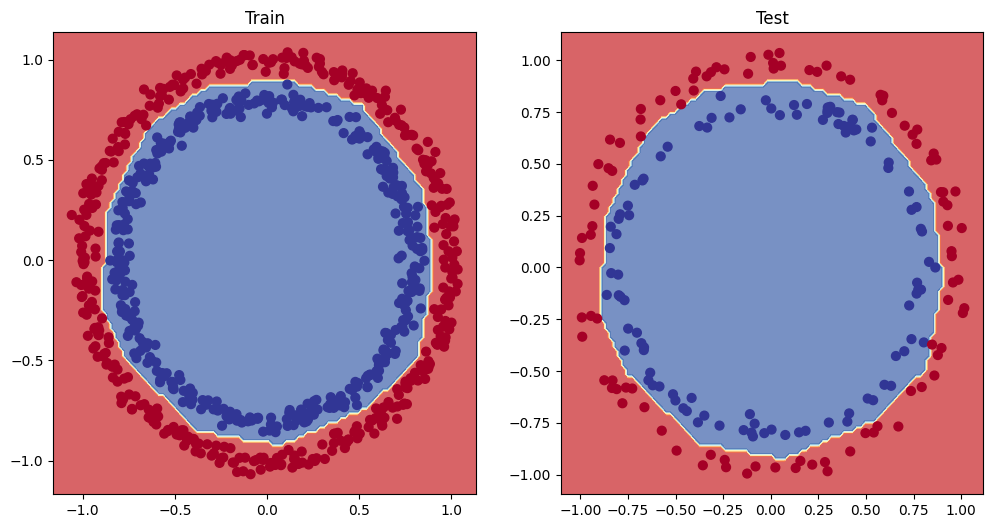

In [59]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)

In [65]:
A = torch.arange(-10, 10, .1, dtype=torch.float32)

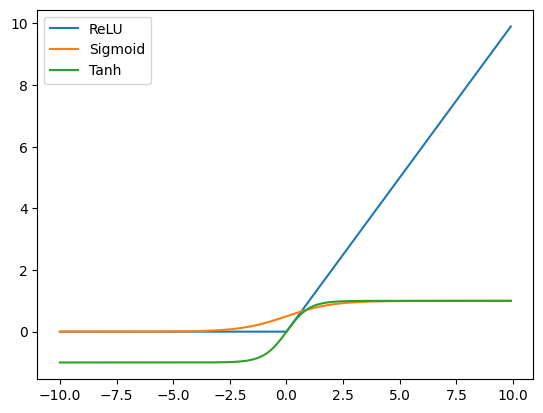

In [66]:
plt.plot(A, torch.relu(A), label = "ReLU") # plot ReLU function
plt.plot(A, torch.sigmoid(A), label = "Sigmoid") # plot Sigmoid function
plt.plot(A, torch.tanh(A), label = "Tanh") # plot Tanh function
plt.legend()
plt.show()

## Putting all together with Multi-class classification

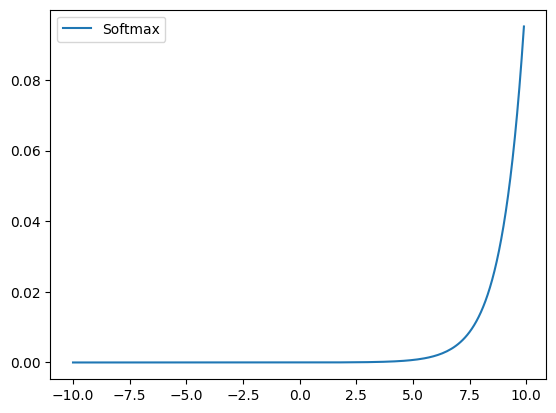

In [67]:
plt.plot(A, torch.softmax(A, dim=0), label = "Softmax") # plot Softmax function
plt.legend()
plt.show()

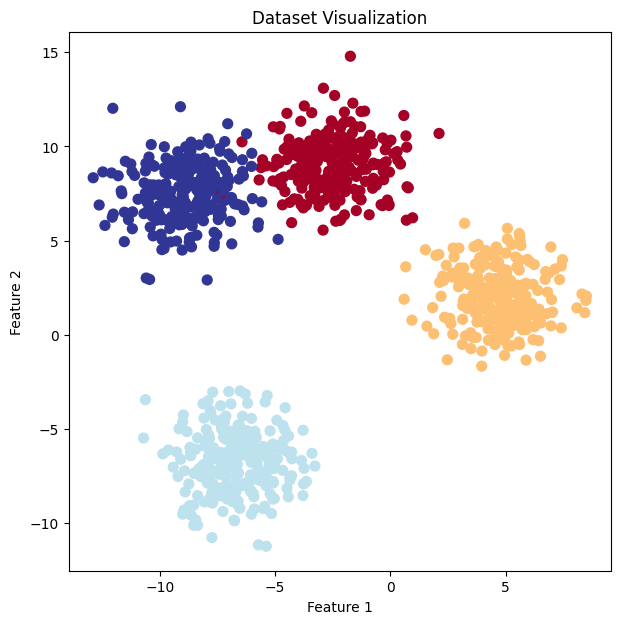

In [68]:
from sklearn.datasets import make_blobs
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42 # hyperparameter for reproducibility capital letters

#1 . Create a dataset with 4 classes and 2 features using the make_blobs function from sklearn. The make_blobs function generates isotropic Gaussian blobs for clustering. We can specify the number of samples, number of features, number of centers (classes), and random state for reproducibility.
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5, #give randomness to the dataset
                            random_state=RANDOM_SEED)

# 2. turn dataset into tensors for PyTorch. PyTorch models expect input data to be in the form of tensors. We can convert the NumPy arrays returned by make_blobs into PyTorch tensors using torch.from_numpy and specify the data type as torch.float for the features and torch.long for the labels.
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float) # for multi-class classification

# 3. split the dataset into training and testing sets using train_test_split from sklearn. We can specify the test size and random state for reproducibility.
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

# 4. plort the dataset using matplotlib to visualize the distribution of the classes in the feature space. We can use a scatter plot to show the data points and color them based on their class labels.
plt.figure(figsize=(7, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu, s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset Visualization")
plt.show()

### Building a multi-class classification model

In [69]:
# create device agnostic code to check if GPU is available and use it for training the model. If a GPU is not available, the code will fall back to using the CPU. This allows for faster training on machines with compatible hardware.
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
device

'mps'

In [70]:
class BlobModelV0(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            #nn.ReLU(), # add non-linear activation function
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            #nn.ReLU(), # add non-linear activation function
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

In [71]:
model_blob = BlobModelV0(input_features=NUM_FEATURES, output_features=NUM_CLASSES, hidden_units=8).to(device)
model_blob

BlobModelV0(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [72]:
model_blob.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998]], device='mps:0')),
             ('linear_layer_stack.0.bias',
              tensor([ 0.5451,  0.1045, -0.3301,  0.1802, -0.3258, -0.0829, -0.2872,  0.4691],
                     device='mps:0')),
             ('linear_layer_stack.1.weight',
              tensor([[-0.2791, -0.1630, -0.0998, -0.2126,  0.0334, -0.3492,  0.3193, -0.3003],
                      [ 0.2730,  0.0588, -0.1148,  0.2185,  0.0551,  0.2857,  0.0387, -0.1115],
                      [ 0.0950, -0.0959,  0.1488,  0.3157,  0.2044, -0.1546,  0.2041,  0.0633],
                      [ 0.1795, -0.2155, -0.3500, -0.1366, -0.2712,  0.2901,  0.1018,  0.1

In [75]:
next(model_blob.parameters()).device

device(type='mps', index=0)

In [76]:
torch.unique(y_blob_train)

tensor([0., 1., 2., 3.])

In [77]:
# optimizer and loss function for multi-class classification. For multi-class classification, we can use the CrossEntropyLoss as the loss function. The CrossEntropyLoss combines the LogSoftmax and NLLLoss in one single class. It is suitable for multi-class classification tasks where the target labels are integers representing the class indices. We can use the Adam optimizer for updating the model's parameters during training.
loss_fn = nn.CrossEntropyLoss() # for multi-class classification
optimizer = torch.optim.Adam(model_blob.parameters(), lr=0.01) # for multi-class

In [79]:
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

In [80]:
model_blob(X_blob_train[:5])

tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
        [ 0.2210, -1.5439,  0.0420,  1.1531],
        [ 2.8698,  0.9143,  3.3169,  1.4027],
        [ 1.9576,  0.3125,  2.2244,  1.1324],
        [ 0.5458, -1.2381,  0.4441,  1.1804]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [ ]:
model_blob.eval() # set model to evaluation mode
with torch.inference_mode():
    y_pred = model_blob(X_blob_test) #these are logits, not probabilities
y_pred[:10]

# logits (raw outputs) -> probs -> label predictions. For multi-class classification, we can convert the logits to probabilities using the softmax function. The softmax function takes a vector of logits and converts them into a probability distribution over the classes. We can then use the argmax function to get the predicted class labels based on the highest probability.

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852],
        [ 2.0878, -1.3728,  2.1248,  2.5052],
        [ 1.8310,  0.8851,  2.1674,  0.6006],
        [ 0.1412, -1.4742, -0.0360,  1.0373],
        [ 2.9426,  0.7047,  3.3670,  1.6184],
        [-0.0645, -1.5006, -0.2666,  0.8940]], device='mps:0')

In [82]:
y_blob_test[:10]

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.], device='mps:0')

In [ ]:
# convert logits to probabilities using softmax function
y_pred_probs = torch.softmax(y_pred, dim=1) # convert logits to probabilities using softmax function
print(f"Predicted probabilities: {y_pred_probs[:10]}") #argmax to get predicted class labels based on highest probability
print(f"True labels: {y_blob_test[:10]}")

Predicted probabilities: tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951],
        [0.2788, 0.0088, 0.2893, 0.4232],
        [0.3246, 0.1261, 0.4545, 0.0948],
        [0.2229, 0.0443, 0.1867, 0.5461],
        [0.3447, 0.0368, 0.5269, 0.0917],
        [0.2145, 0.0510, 0.1752, 0.5593]], device='mps:0')
True labels: tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.], device='mps:0')


In [85]:
print(f"Predicted class labels: {torch.argmax(y_pred_probs, dim=1)[:10]}") # get predicted class labels based on highest probability
print(f"True labels: {y_blob_test[:10]}")

Predicted class labels: tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3], device='mps:0')
True labels: tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.], device='mps:0')


In [87]:
torch.manual_seed(42)
torch.mps.manual_seed(42) if torch.backends.mps.is_available() else None

epochs = 1000

for epoch in range(epochs):
    model_blob.train()

    #1. forward pass
    y_logits = model_blob(X_blob_train) # forward pass

    #2. compute loss and accuracy
    loss = loss_fn(y_logits, y_blob_train.long()) # compute loss #CrossEntropy

    #3. backpropagation and optimization
    optimizer.zero_grad() # zero the gradients

    # 4. loss backward and optimizer step
    loss.backward() # backpropagation

    #5. optimizer step
    optimizer.step() # update parameters

    # test
    model_blob.eval() # set model to evaluation mode
    with torch.inference_mode():
        test_logits = model_blob(X_blob_test) # forward pass
        test_loss = loss_fn(test_logits, y_blob_test.long()) # compute loss
        test_pred = torch.argmax(test_logits, dim=1) # get predicted class labels based on highest probability
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred) # compute accuracy
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.0170 | Test Loss: 0.0040 | Test Accuracy: 100.00%
Epoch: 100 | Loss: 0.0170 | Test Loss: 0.0040 | Test Accuracy: 100.00%
Epoch: 200 | Loss: 0.0170 | Test Loss: 0.0040 | Test Accuracy: 100.00%
Epoch: 300 | Loss: 0.0170 | Test Loss: 0.0040 | Test Accuracy: 100.00%
Epoch: 400 | Loss: 0.0170 | Test Loss: 0.0040 | Test Accuracy: 100.00%
Epoch: 500 | Loss: 0.0170 | Test Loss: 0.0040 | Test Accuracy: 100.00%
Epoch: 600 | Loss: 0.0171 | Test Loss: 0.0044 | Test Accuracy: 100.00%
Epoch: 700 | Loss: 0.0170 | Test Loss: 0.0039 | Test Accuracy: 100.00%
Epoch: 800 | Loss: 0.0170 | Test Loss: 0.0039 | Test Accuracy: 100.00%
Epoch: 900 | Loss: 0.0170 | Test Loss: 0.0039 | Test Accuracy: 100.00%


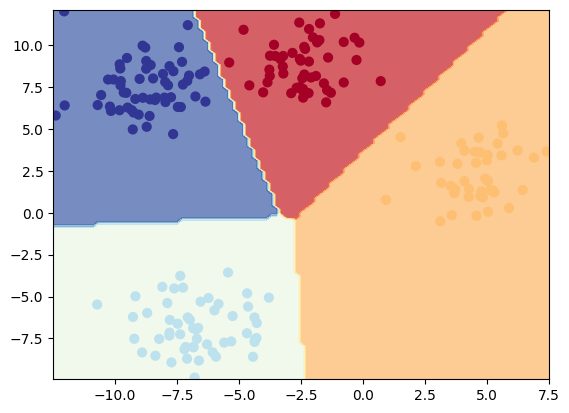

In [88]:
plot_decision_boundary(model_blob, X_blob_test, y_blob_test)

Text(0.5, 1.0, 'Test')

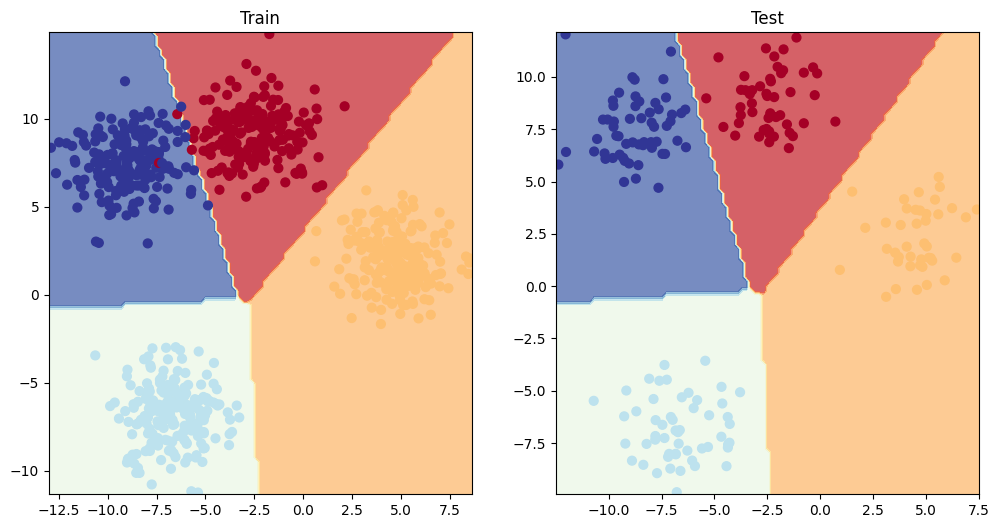

In [89]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_decision_boundary(model_blob, X_blob_train, y_blob_train)
plt.title("Train")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_blob, X_blob_test, y_blob_test)
plt.title("Test")


In [90]:
#linearly separable dataset is a dataset where the classes can be separated by a straight line (or hyperplane in higher dimensions). In contrast, a non-linearly separable dataset is one where the classes cannot be separated by a straight line. The blobs dataset we created earlier is an example of a linearly separable dataset, while the circles dataset is an example of a non-linearly separable dataset.

## A few more classification metrics

* Accuracy - good for balanced
* Precision
* Recall
* confusion matrix
* classification report


In [93]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [103]:
import torchmetrics
metric = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(device) # for multi-class classification
torchmetric_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(device)

torchmetric_accuracy(test_pred, y_blob_test.long())


tensor(1., device='mps:0')